<a href="https://colab.research.google.com/github/nikita082000/DTEY/blob/%D0%9A%D0%A1%D0%92%D0%94/Nikytenko_Final_Test__2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files

sns.set(style="whitegrid")

In [11]:
uploaded = files.upload()
df = pd.read_csv('shopping_trends.csv')

df.head()

Saving shopping_trends.csv to shopping_trends (3).csv


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [12]:
print("Розмір таблиці:", df.shape)
print("\nПропуски по стовпцях:")
print(df.isna().sum())
print("\nТипи стовпців:")
print(df.dtypes)

Розмір таблиці: (3900, 19)

Пропуски по стовпцях:
Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

Типи стовпців:
Customer ID                   int64
Age                           int64
Gender                       object
Item Purchased               object
Category                     object
Purchase Amount (USD)         int64
Location                     object
Size                         object
Color                        object
Season                     

In [13]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
print("Нові назви стовпців:")
print(df.columns.tolist())
df.head()

Нові назви стовпців:
['customer_id', 'age', 'gender', 'item_purchased', 'category', 'purchase_amount_(usd)', 'location', 'size', 'color', 'season', 'review_rating', 'subscription_status', 'payment_method', 'shipping_type', 'discount_applied', 'promo_code_used', 'previous_purchases', 'preferred_payment_method', 'frequency_of_purchases']


,customer_id,age,gender,item_purchased,category,purchase_amount_(usd),location,size,color,season,review_rating,subscription_status,payment_method,shipping_type,discount_applied,promo_code_used,previous_purchases,preferred_payment_method,frequency_of_purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


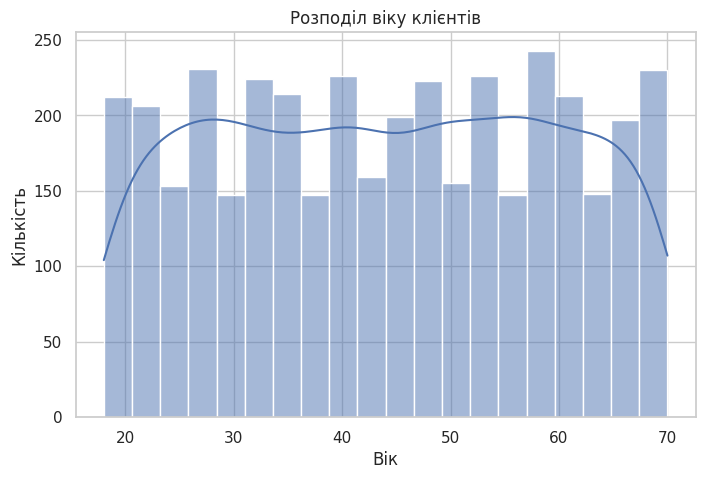

In [14]:
# 1) Гістограма віку (age)
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='age', bins=20, kde=True)
plt.title('Розподіл віку клієнтів')
plt.xlabel('Вік')
plt.ylabel('Кількість')
plt.show()

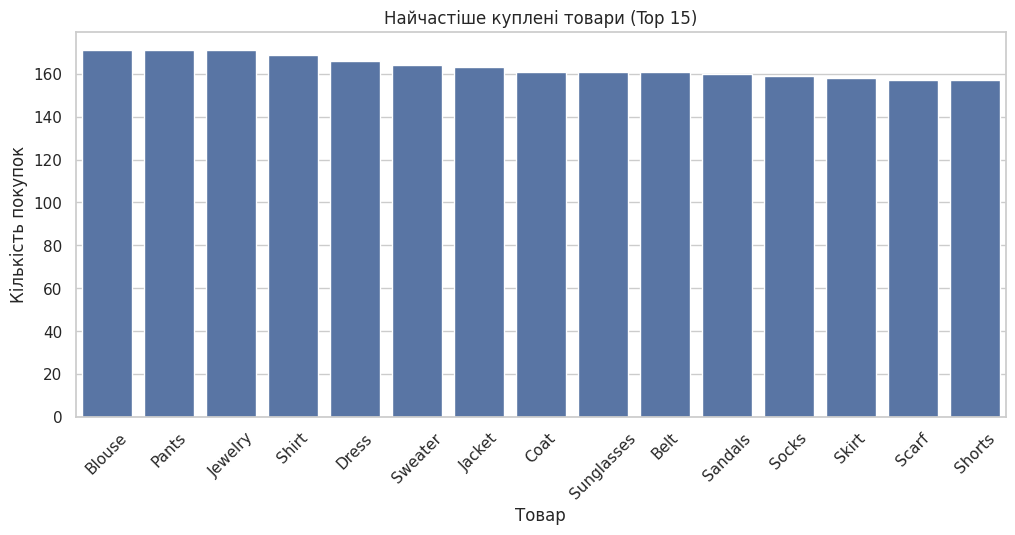

In [15]:
# 2-3) Порівняння розподілу покупок за товарами (item_purchased)
top_items = df['item_purchased'].value_counts().head(15).index
plt.figure(figsize=(12,5))
sns.countplot(data=df[df['item_purchased'].isin(top_items)],
              x='item_purchased',
              order=top_items)
plt.title('Найчастіше куплені товари (Top 15)')
plt.xlabel('Товар')
plt.ylabel('Кількість покупок')
plt.xticks(rotation=45)
plt.show()

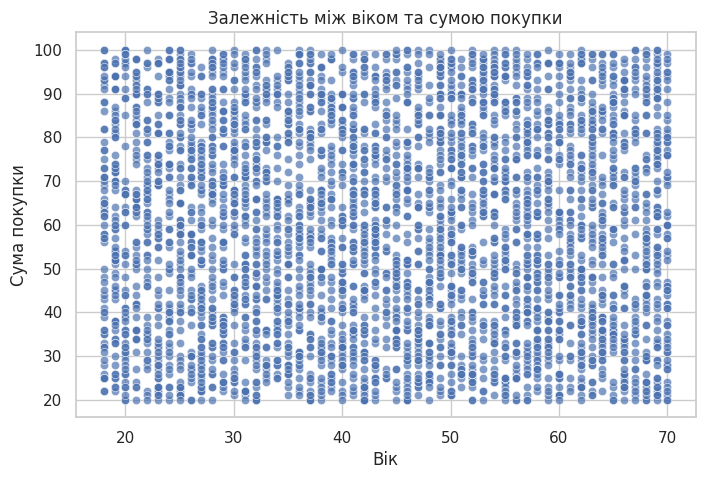

In [20]:
# 4-5) Залежність між віком та сумою покупок (purchase_amount_usd)

amount_col = 'purchase_amount_(usd)' if 'purchase_amount_(usd)' in df.columns else 'purchase_amount'
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='age', y=amount_col, alpha=0.7)
plt.title('Залежність між віком та сумою покупки')
plt.xlabel('Вік')
plt.ylabel('Сума покупки')
plt.show()

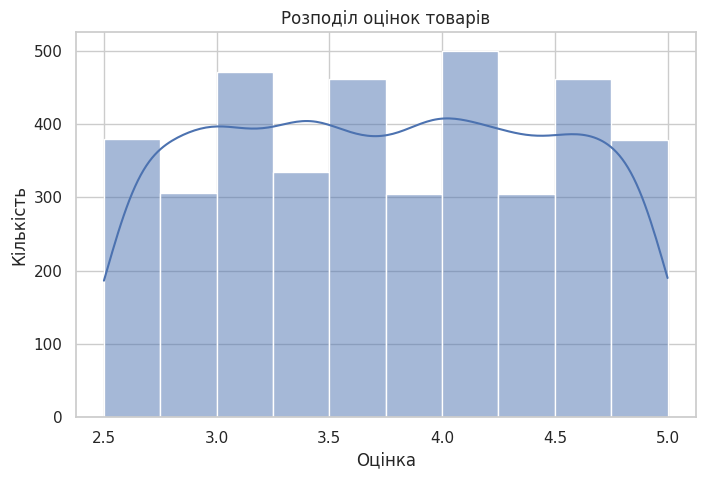

In [23]:
# 6-7. Розподіл оцінок товарів (review_rating)

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='review_rating', bins=10, kde=True)
plt.title('Розподіл оцінок товарів')
plt.xlabel('Оцінка')
plt.ylabel('Кількість')
plt.show()

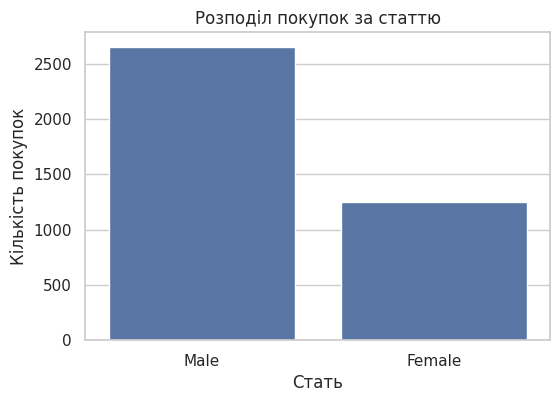

In [24]:
# 8-9. Категоріальна діаграма для статі (gender)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='gender')
plt.title('Розподіл покупок за статтю')
plt.xlabel('Стать')
plt.ylabel('Кількість покупок')
plt.show()

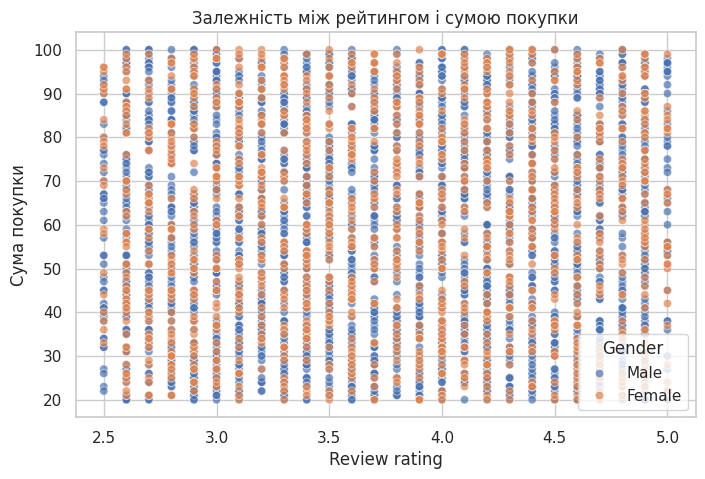

In [25]:
# 10. Залежність між review_rating і purchase_amount

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='review_rating', y=amount_col, hue='gender', alpha=0.7)
plt.title('Залежність між рейтингом і сумою покупки')
plt.xlabel('Review rating')
plt.ylabel('Сума покупки')
plt.legend(title='Gender')
plt.show()